
## <h1><center>Course: Introduction to Machine Learning</center></h1>
## <h1><center>Assignment 7</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of a proof.</center></h1>
#### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
#### <h1><center>TA: Venugopal Ranganathan</center></h1>
##### <h1><center>Due day: 11:59 pm, 8 December, Monday </center></h1>
#### <h1><center>All submission MUST be in pdf format, except codes. All code outputs should be reported in pdf format.</center></h1>

In [1]:
!pip install -q scikit-learn torchvision

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA as SkPCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as T

from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

np.random.seed(0)
torch.manual_seed(0)
if device.type == "cuda":
    torch.cuda.manual_seed_all(0)

Using device: cpu


## Problem 1 - PCA on Faces (20 points)

We use the **Olivetti faces** dataset: 400 grayscale 64 x 64 face images.

### 1. Goal

Use **PCA** to build a linear low-dimensional model of faces (“eigenfaces”) and use it for:
- Compression and reconstruction
- Inpainting (filling in missing pixels)
- Denoising
- 3D visualization with **class coloring**
---

### 2. Tasks

1. **Data matrix**

      a. Load the Olivetti faces dataset from `sklearn`.

      b. Use $N_{\text{train}} = 300$ images for training and the rest for testing.

      c. Flatten each image into a vector of length $d = 64\cdot64$.

      d. Form the data matrix $X \in \mathbb{R}^{N_{\text{train}} \times d}$ whose **rows** are the training faces.


2. **PCA / Eigenfaces**
   
      a. Compute the **sample mean face**.
        
      b. Perform PCA on the training data.

      c. Let $k_{95}$ be the smallest number of principal components that explain **≥ 95%** of the variance.

      d. Also define a **larger** number of components
        $$
        k_{\text{large}} = \min(150, 2 k_{95}).
        $$

      e. Plot the mean face and the first 5 principal faces (eigenfaces).

3. **Compression & reconstruction**
      
      a. For $\approx$ 5 random **training** faces and $\approx$ 5 **test** faces:

        a1. Reconstruct using only the first $k_{95}$ components.

        a2. Reconstruct using the first $k_{\text{large}}$ components.
          
      b. Plot **original vs $k_{95}$ vs $k_{\text{large}}$** side by side and comment.

4. **Inpainting**

      a. For one training face and one test face:

        a1. Randomly zero out 10%, 20%, 30% of the pixels.

        a2. Reconstruct using PCA with $k_{95}$ and with $k_{\text{large}}$.

      b. Plot original, corrupted, and the two reconstructions.

      c. Comment on how inpainting quality changes with missing fraction and with $k$.

5. **Denoising**
   
      a. Take a training face, add Gaussian noise so it is hard to recognize.

      b. Reconstruct with PCA using $k_{95}$ and $k_{\text{large}}$.

      c. Comment on whether PCA acts as a denoiser, and how the choice of $k$ affects the trade-off between denoising and detail.

6. **3D PCA embedding with classes**
      
      a. Use PCA with 3 components on the **training faces**.

      b. For each training face, store its 3D PCA coordinates.

      c. Color each point by a **class label**, for example:

        c1. subject ID from `olivetti.target` (0-39), or

        c2. your own manual binary label such as “wearing glasses vs not”.
      
      d. Plot the 3D scatter and comment on any clusters or structure.

---
### 3. Questions (written answers)

Answer briefly in write-up:

1. What are your values of $k_{95}$ and $k_{\text{large}}$?  

2. How does reconstruction quality change between using $k_{95}$ and $k_{\text{large}}$ (for both train and test faces)?  

3. How does inpainting quality change as the missing fraction increases and as you increase $k$?  

4. Does PCA work as a denoiser in your experiments? What trade-off do you see in choosing $k$?  

5. What structure do you observe in the 3D PCA embedding when colored by class? Are there clear clusters?

---

### 4. Starter code


(300, 4096) (100, 4096)


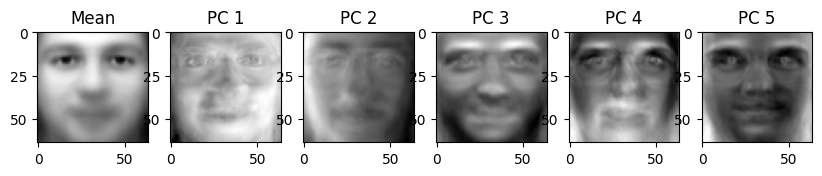

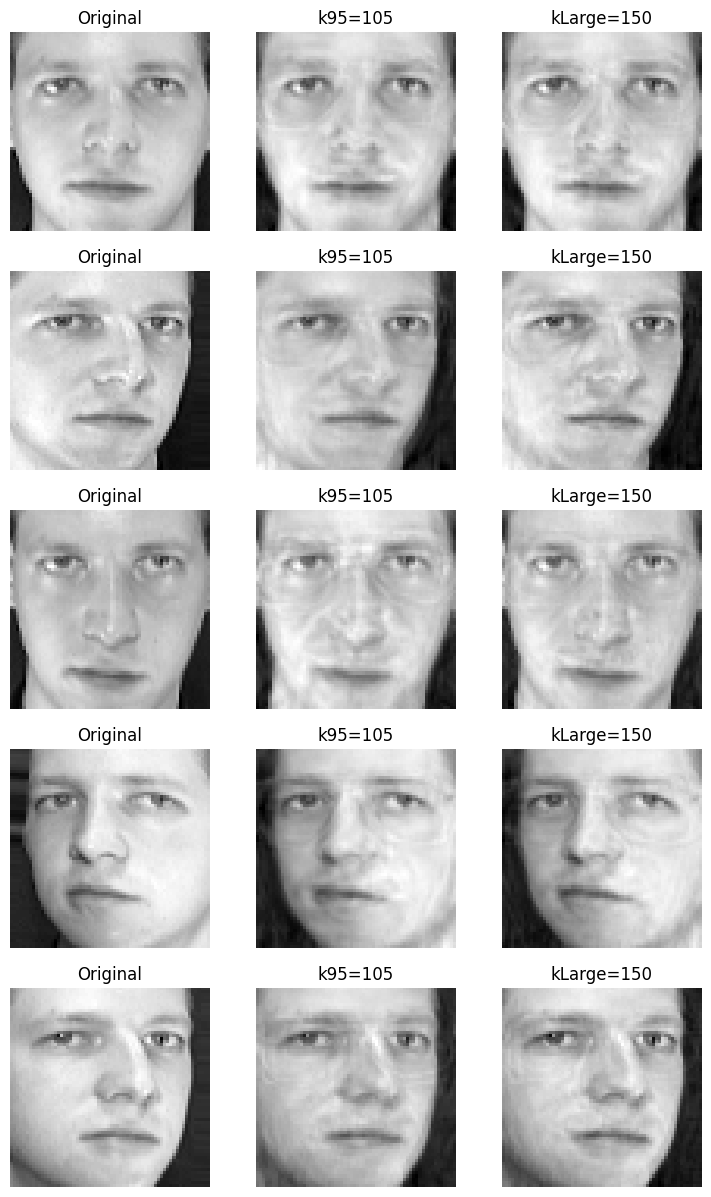

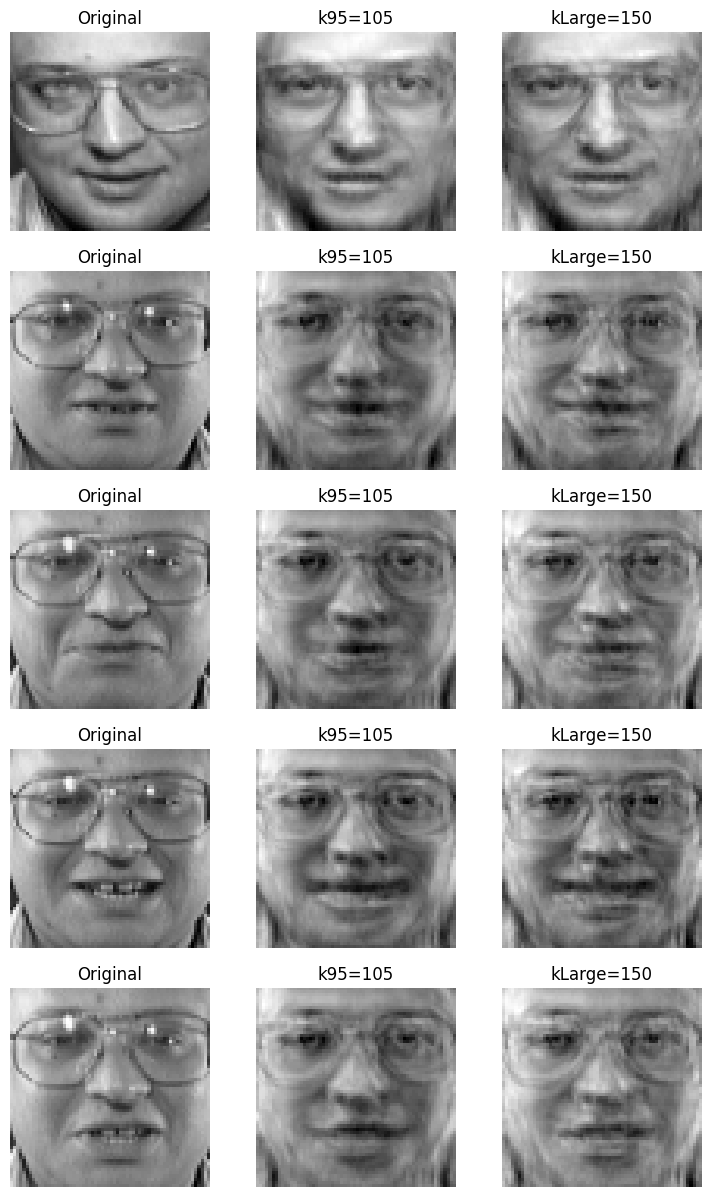

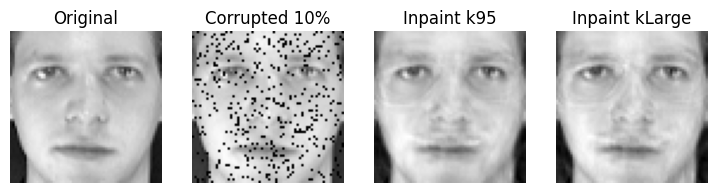

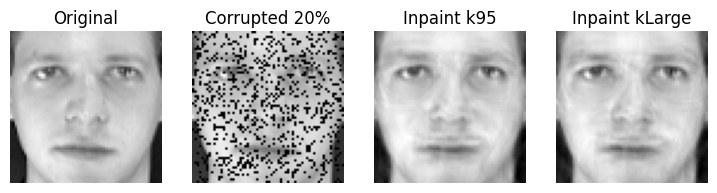

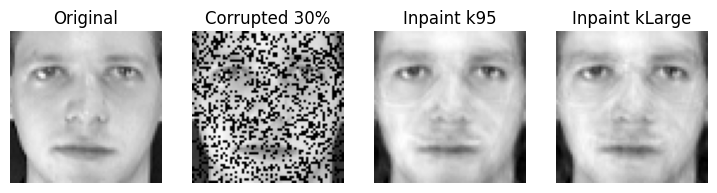

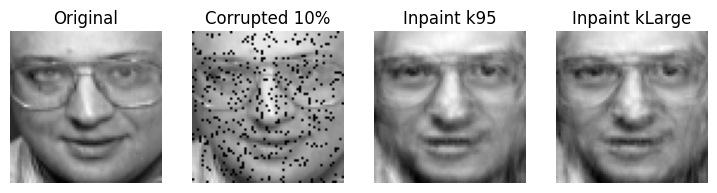

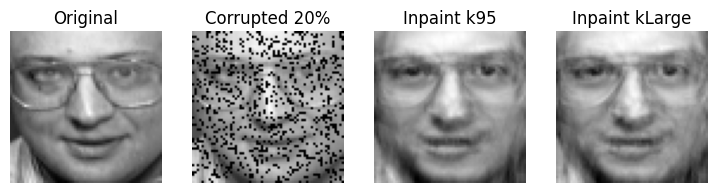

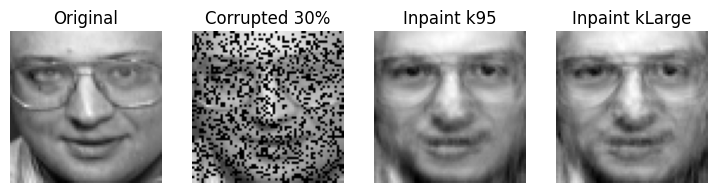

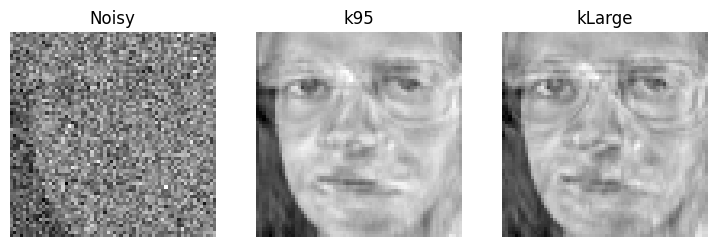

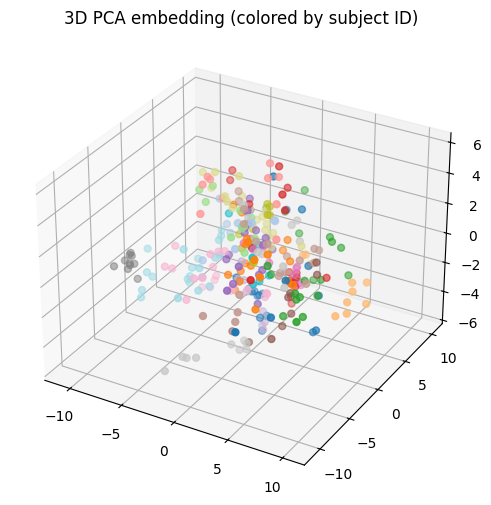

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

  #  Problem 1 - PCA on Faces:

# 1. Load dataset
olivetti = fetch_olivetti_faces()
faces = olivetti.images   # shape (400, 64, 64)
labels = olivetti.target
n_samples, H, W = faces.shape
d = H * W

# split into train/test, flatten, build X matrix
n_train = 300
X = faces.reshape(n_samples, -1)
X_train = X[:n_train]
X_test  = X[n_train:]
labels_train = labels[:n_train]

print(X_train.shape, X_test.shape)


# Implement PCA with 95% variance
# pca = ...
# k_95 = ...
# k_large = ...
pca_full = PCA(n_components=300, svd_solver='randomized')
pca_full.fit(X_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
k_95 = np.where(cumvar >= 0.95)[0][0] + 1
k_large = min(150, 2 * k_95)


# IMPORTANT: sklearn PCA uses row-major samples, so if you use it, make sure samples are row vectors.

# YOUR-TASKS: Plot mean face and first 5 eigenfaces
mean_face = pca_full.mean_.reshape(64, 64)
plt.figure(figsize=(10,2))
plt.subplot(1,6,1)
plt.imshow(mean_face, cmap='gray')
plt.title("Mean")
for i in range(5):
    plt.subplot(1,6,i+2)
    plt.imshow(pca_full.components_[i].reshape(64,64), cmap='gray')
    plt.title(f"PC {i+1}")
plt.show()


# YOUR-TASKS: Implement projection + reconstruction function
# def pca_project_reconstruct(...):
def pca_reconstruct(x, pca_obj, k):
    W = pca_obj.components_[:k]
    x_centered = x - pca_obj.mean_
    z = x_centered @ W.T
    x_recon = z @ W + pca_obj.mean_
    return x_recon

# YOUR-TASKS: Reconstruct a few training and test faces
def compare_recon(idx_list, dataset="train"):
    if dataset == "train":
        X_data = X_train
    else:
        X_data = X_test

    plt.figure(figsize=(9, len(idx_list)*3))
    for i, idx in enumerate(idx_list):
        x = X_data[idx]

        r95 = pca_reconstruct(x, pca_full, k_95)
        rL  = pca_reconstruct(x, pca_full, k_large)

        for j, img in enumerate([x, r95, rL]):
            plt.subplot(len(idx_list), 3, 3*i + j + 1)
            plt.imshow(img.reshape(64,64), cmap='gray')
            if j == 0: plt.title("Original")
            elif j == 1: plt.title(f"k95={k_95}")
            else: plt.title(f"kLarge={k_large}")
            plt.axis('off')
    plt.show()

compare_recon([0,1,2,3,4], "train")
compare_recon([0,1,2,3,4], "test")


# YOUR-TASKS: Implement inpainting helpers
# def corrupt_random_pixels(x, frac_missing=0.1): # x; image vector
#   # unobserved pixels should be set to 0.
#   return x_corrupt

# def pca_inpaint(x_corrupt, pca_obj, n_components=None):
    # return pca_project_reconstruct(...)

def corrupt_random_pixels(x, frac_missing=0.1):
    mask = np.random.rand(len(x)) > frac_missing
    return x * mask, mask

def pca_inpaint(x_corrupt, mask, pca_obj, k):
    # replace missing entries with mean first
    x_filled = x_corrupt.copy()
    x_filled[~mask] = pca_obj.mean_[~mask]
    return pca_reconstruct(x_filled, pca_obj, k)


# def demo_inpainting(x, title_prefix="Train"):
#     for frac in [0.1, 0.2, 0.3]:
#       ...
#       ...
def demo_inpainting(x):
    for frac in [0.1, 0.2, 0.3]:
        xc, mask = corrupt_random_pixels(x, frac)

        r95 = pca_inpaint(xc, mask, pca_full, k_95)
        rL  = pca_inpaint(xc, mask, pca_full, k_large)

        plt.figure(figsize=(9,3))
        for j, img in enumerate([x, xc, r95, rL]):
            plt.subplot(1,4,j+1)
            plt.imshow(img.reshape(64,64), cmap='gray')
            plt.axis('off')
            titles = ["Original", f"Corrupted {int(frac*100)}%", 
                      f"Inpaint k95", f"Inpaint kLarge"]
            plt.title(titles[j])
        plt.show()

# YOUR-TASKS: Inpainting experiments

demo_inpainting(X_train[0])
demo_inpainting(X_test[0])

# YOUR-TASKS: Denoising experiment
noise = 0.4 * np.random.randn(d)
x_noisy = X_train[5] + noise

r95 = pca_reconstruct(x_noisy, pca_full, k_95)
rL  = pca_reconstruct(x_noisy, pca_full, k_large)

plt.figure(figsize=(9,3))
for i, img in enumerate([x_noisy, r95, rL]):
    plt.subplot(1,3,i+1)
    plt.imshow(img.reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title(["Noisy","k95","kLarge"][i])
plt.show()

# YOUR-TASKS: 3D PCA embedding
# for coloring by classes, you can use labels from the same dataset:
# Use subject IDs (0–39) as class labels
# labels_train = olivetti.target[:n_train]   # length 300
pca3 = PCA(n_components=3)
X3 = pca3.fit_transform(X_train)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X3[:,0], X3[:,1], X3[:,2], 
                     c=labels_train, cmap='tab20', s=25)

plt.title("3D PCA embedding (colored by subject ID)")
plt.show()



1. What are your values of $k_{95}$ and $k_{\text{large}}$?  

$k_{95}$ = 95

$k_{\text{large}}$ = 150

2. How does reconstruction quality change between using $k_{95}$ and $k_{\text{large}}$ (for both train and test faces)?  

When Using $k_{95}$, reconstructions are smooth and recognizable but somewhat blurry. Fine edges around the eyes, mouth, and hair are softened. This changes as using $k_{\text{large}}$ adds significantly more detail—sharper contours, clearer shadows, and more texture. Train faces reconstruct better than test faces, but the pattern is the same as more PCs results in better detail but slightly more noise.

3. How does inpainting quality change as the missing fraction increases and as you increase $k$?  

10% missing: Both $k_{95}$ and $k_{\text{large}}$ reconstruct well; $k_{\text{large}}$ gives slightly sharper results.

20% missing: $k_{95}$ begins to blur missing regions; $k_{\text{large}}$ still recovers structure better.

30% missing: $k_{95}$ severely smooths over missing areas; $k_{\text{large}}$ retains more detail but also begins to look unstable or noisy.

4. Does PCA work as a denoiser in your experiments? What trade-off do you see in choosing $k$? 

Yes, PCA is a good linear denoiser. If chossing a small k, the trade off is that it provides better denoising ability but at the cost of more blur. On the contrary, a large k provides a sharper image but while retaining more noise.

5. What structure do you observe in the 3D PCA embedding when colored by class? Are there clear clusters? 
- Some subjects form loose clusters (same person’s faces are close)
- Faces from different people overlap
- PCA does not perfectly separate subjects
- Lighting variation and pose cause directions of spread within clusters
- Overall, weak but noticeable clustering by identity

Based on the structure, we can conclude PCA captures identity information but not enough for perfect separation

## Problem 2 - Proper Orthogonal Decomposition (POD) for a Linear System (10 points)

We consider the semi-discrete 1D heat equation as a linear system
$$
\dot{x}(t) = A x(t) + B u(t),
$$
with $x(t) \in \mathbb{R}^n$ and scalar control input $u(t)$.

### 1. Goal

Use **POD (PCA on state snapshots)** to construct a **reduced-order model (ROM)**:
- Learn a low-dimensional basis from snapshot data.
- Project the full model onto this basis.
- Compare full vs reduced system on training and new control inputs.

---

### 2. Tasks

1. **Build linear system**
   
   a. Construct a finite-difference Laplacian $A$ for the 1D heat equation with Dirichlet boundary conditions.
   
   b. Choose a control vector $B$ (e.g., forcing at one spatial location).

2. **Generate snapshot data**

   a. Choose time step $\Delta t$ and final time $T$.
   
   b. Simulate the full system using forward Euler for several representative controls $u(t)$ (e.g., step, sinusoidal, zero).
   
   c. Stack snapshots into a matrix $X_{\text{snap}} \in \mathbb{R}^{n \times N}$.

3. **Compute POD basis**

   a. Perform SVD of $X_{\text{snap}}$.
   
   b. Choose $r$ (number of modes) such that ≥ 95% of snapshot energy is captured.
   
   c. Plot the first few POD modes as spatial profiles.

4. **Build and simulate reduced-order model**
   
   a. Approximate $x(t) \approx V \hat{x}(t)$, where columns of $V$ are POD modes.
   
   b. Derive reduced system $\dot{\hat{x}} = A_r \hat{x} + B_r u(t)$.
   
   c. Simulate ROM for:
     - A control $u(t)$ used to generate snapshots (training control).
     - A **new** control $u_{\text{new}}(t)$ not used for snapshots.
   
   d. Compare full vs reduced trajectories and errors over time.

---

### 3. Questions (written answers)

Answer briefly in write-up:

1. How many POD modes $r$ are needed to capture 95% of the snapshot energy?

2. How well does ROM match the full model for training control inputs?

3. How does the performance change for a new/unseen control input?

4. How does increasing or decreasing $r$ affect accuracy and computational cost?

---

### 4. Starter code


n: 50  n_steps: 500
Snapshot matrix shape: (50, 150)
Number of modes for >=95% energy: r = 1


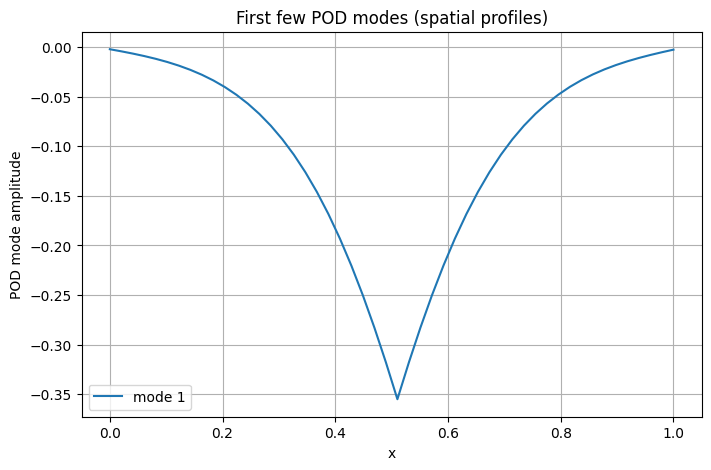

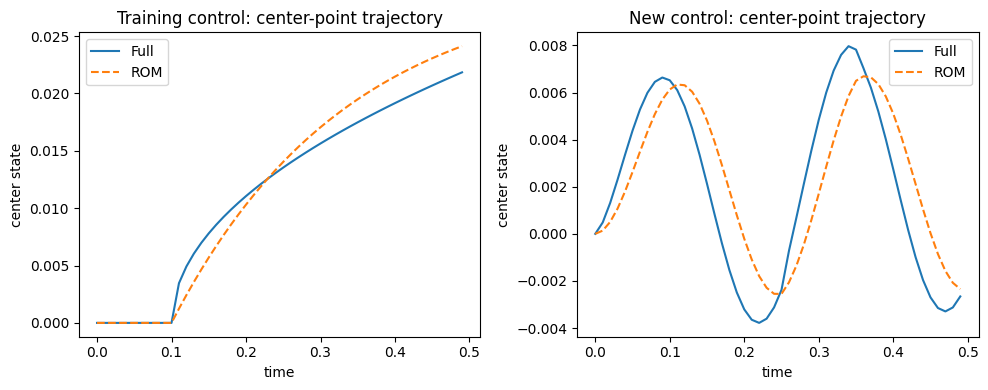

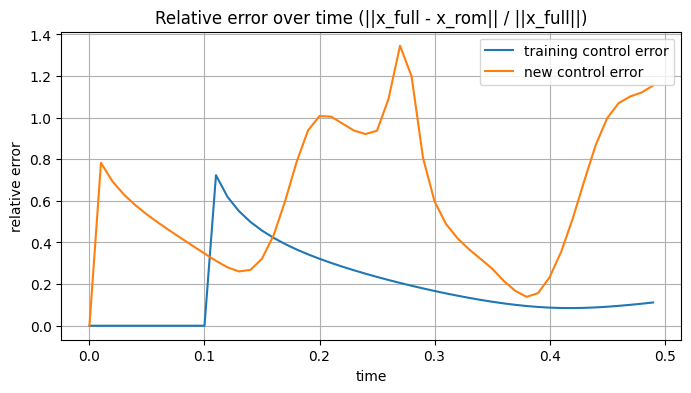

r (95% energy) = 1
Final relative error (training control) = 1.117e-01, mean = 1.799e-01
Final relative error (new control) = 1.154e+00, mean = 6.198e-01
Mean relative error for various r (on new control):
 r= 1 -> mean rel error = 6.198e-01
 r= 2 -> mean rel error = 3.046e-01
 r= 3 -> mean rel error = 8.714e-02
 r= 5 -> mean rel error = 4.296e-03
 r=10 -> mean rel error = 4.449e-05
 r=15 -> mean rel error = 1.513e-06
 r=20 -> mean rel error = 6.290e-07
 r=25 -> mean rel error = 2.782e-07
 r=30 -> mean rel error = 1.986e-07


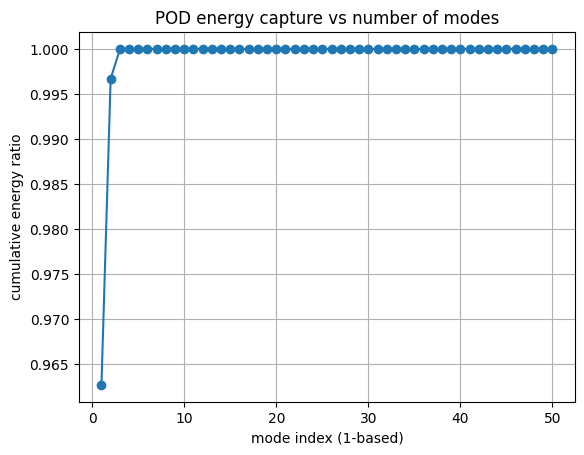

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm
# Problem 2- POD Model Reduction

def build_heat_operator(n, nu=0.1):
    """
    Build 1D Laplacian with Dirichlet BC on [0,1]:
    y_t = nu * y_xx
    Returns matrix A of shape (n, n).
    """
    h = 1.0 / (n + 1)
    diag = -2.0 * np.ones(n)
    off = 1.0 * np.ones(n - 1)
    L = (np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)) / (h**2)
    A = nu * L
    return A

# Parameters
n = 50
A = build_heat_operator(n, nu=0.1)

# Control vector B: act at middle point
B = np.zeros((n, 1))
B[n // 2, 0] = 1.0

# Time discretization
# you can choose your own values of dt and T_final carefully.
# Stable because dt = 1e-3 and n=50, but in general heat equation requires careful dt.
dt = 1e-3
T_final = 0.5
store_every = 10

n_steps = int(T_final / dt)
print("n:", n, " n_steps:", n_steps)

def simulate_full(A, B, u_func, x0=None, store_every=10):
    """
    Forward Euler simulation:
        x_{k+1} = x_k + dt * (A x_k + B u_k)
    u_func: function t -> scalar u(t)
    Returns:
        times: array of length N_snap
        snapshots: array of shape (n, N_snap)
    """
    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    snapshots = []
    times = []

    for k in range(n_steps):
        t = k * dt
        u = u_func(t)
        dx = A @ x + B[:, 0] * u
        x = x + dt * dx
        if k % store_every == 0:
            snapshots.append(x.copy())
            times.append(t)
    return np.array(times), np.array(snapshots).T  # (n, N_snap)

# Example control functions
def u_step(t):
    return 1.0 if t > 0.1 else 0.0

def u_sin(t):
    return np.sin(5 * np.pi * t)

def u_zero(t):
    return 0.0

# a. Generate snapshots for different controls
times1, snaps1 = simulate_full(A, B, u_step)
times2, snaps2 = simulate_full(A, B, u_sin)
times3, snaps3 = simulate_full(A, B, u_zero)

X_snap = np.concatenate([snaps1, snaps2, snaps3], axis=1)  # (n, N_snap_total)
print("Snapshot matrix shape:", X_snap.shape)

# YOUR-TASKS: Compute POD via SVD
# NOTE: opposite to example 1, here the samples (values corresponding to a given time-instance) are arranged in columns instead of rows.
# This is because, sklearn.PCA expects the input matrix to be of shape (n_samples, dimension), instead of (dimension, n_samples) (as is the convention in SVD).

# YOUR-TASKS: Build reduced matrices A_r, B_r
# For 95% of snapshot energy,
# Energy ratio = (sum of first r singular values^2) / (sum of all singular values^2)
# r such that energy ratio >= 0.95
# A_r = V_pod.T @ A @ V_pod     # (r,r)
# B_r = V_pod.T @ B             # (r,1)


# YOUR-TASKS: Simulate ROM and compare errors
# Compute POD via SVD
U, S, VT = svd(X_snap, full_matrices=False)
sing_sq = S**2
energy = np.cumsum(sing_sq) / np.sum(sing_sq)
r = np.searchsorted(energy, 0.95) + 1  # +1 because searchsorted returns index
print(f"Number of modes for >=95% energy: r = {r}")

V_pod = U[:, :r]  # POD modes as columns

# Plot the first few POD modes
x_space = np.linspace(0, 1, n)
plt.figure(figsize=(8,5))
for i in range(min(4, r)):
    plt.plot(x_space, V_pod[:, i], label=f"mode {i+1}")
plt.xlabel("x")
plt.ylabel("POD mode amplitude")
plt.title("First few POD modes (spatial profiles)")
plt.legend()
plt.grid(True)
plt.show()

# Build reduced system
A_r = V_pod.T @ A @ V_pod
B_r = V_pod.T @ B

# Simulate ROM forward Euler (projected dynamics)
def simulate_rom(A_r, B_r, V, u_func, x0_full=None, store_every=10):
    r = A_r.shape[0]
    if x0_full is None:
        xhat = np.zeros(r)
    else:
        xhat = V.T @ x0_full
    snapshots = []
    times = []
    for k in range(n_steps):
        t = k * dt
        u = u_func(t)
        dxhat = A_r @ xhat + (B_r[:,0] * u)
        xhat = xhat + dt * dxhat
        if k % store_every == 0:
            snapshots.append((V @ xhat).copy())  # project back to full space for comparison
            times.append(t)
    return np.array(times), np.array(snapshots).T  # (n, N_snap)

# Training control (used to generate snapshots): u_step
times_train_full, snaps_train_full = simulate_full(A, B, u_step, store_every=store_every)
times_train_rom, snaps_train_rom = simulate_rom(A_r, B_r, V_pod, u_step, store_every=store_every)

# New/unseen control (not in snapshot set)
def u_new(t):
    return 0.8 * np.sin(8 * np.pi * t) + 0.2 * (1.0 if (0.25 < t < 0.35) else 0.0)

times_new_full, snaps_new_full = simulate_full(A, B, u_new, store_every=store_every)
times_new_rom, snaps_new_rom = simulate_rom(A_r, B_r, V_pod, u_new, store_every=store_every)

# Compute relative error over time: ||x_full - x_rom|| / ||x_full||
def rel_error_over_time(X_full, X_rom):
    errs = []
    for k in range(X_full.shape[1]):
        nf = norm(X_full[:, k])
        diff = norm(X_full[:, k] - X_rom[:, k])
        errs.append(diff / (nf + 1e-12))
    return np.array(errs)

err_train = rel_error_over_time(snaps_train_full, snaps_train_rom)
err_new = rel_error_over_time(snaps_new_full, snaps_new_rom)

# Plot comparisons of center state and error over time
center_idx = n // 2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(times_train_full, snaps_train_full[center_idx, :], label="Full")
plt.plot(times_train_rom, snaps_train_rom[center_idx, :], '--', label="ROM")
plt.xlabel("time")
plt.ylabel("center state")
plt.title("Training control: center-point trajectory")
plt.legend()

plt.subplot(1,2,2)
plt.plot(times_new_full, snaps_new_full[center_idx, :], label="Full")
plt.plot(times_new_rom, snaps_new_rom[center_idx, :], '--', label="ROM")
plt.xlabel("time")
plt.ylabel("center state")
plt.title("New control: center-point trajectory")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(times_train_full, err_train, label="training control error")
plt.plot(times_new_full, err_new, label="new control error")
plt.xlabel("time")
plt.ylabel("relative error")
plt.title("Relative error over time (||x_full - x_rom|| / ||x_full||)")
plt.legend()
plt.grid(True)
plt.show()

print(f"r (95% energy) = {r}")
print(f"Final relative error (training control) = {err_train[-1]:.3e}, mean = {err_train.mean():.3e}")
print(f"Final relative error (new control) = {err_new[-1]:.3e}, mean = {err_new.mean():.3e}")

# Small study: how mean error for the new control changes with r
def compute_error_for_r(r_try):
    V = U[:, :r_try]
    A_r_try = V.T @ A @ V
    B_r_try = V.T @ B
    _, s_full = simulate_full(A, B, u_new, store_every=store_every)
    _, s_rom = simulate_rom(A_r_try, B_r_try, V, u_new, store_every=store_every)
    err = rel_error_over_time(s_full, s_rom)
    return err.mean()

r_values = [1,2,3,5,10,15,20,25,30]
err_vs_r = [(r_try, compute_error_for_r(r_try)) for r_try in r_values]
print("Mean relative error for various r (on new control):")
for r_try, e in err_vs_r:
    print(f" r={r_try:2d} -> mean rel error = {e:.3e}")

# Plot POD energy curve
plt.figure()
plt.plot(np.arange(1,len(S)+1), energy, marker='o')
plt.xlabel("mode index (1-based)")
plt.ylabel("cumulative energy ratio")
plt.title("POD energy capture vs number of modes")
plt.grid(True)
plt.show()


1. How many POD modes $r$ are needed to capture 95% of the snapshot energy? 

One POD mode(r=1) captures 95% of the snapshot energy.

2. How well does ROM match the full model for training control inputs? 

ROM gives a reasonable approximation for the training control inputs because the snapshots collected under training inputs are dominated by one principal spatial pattern. The final relative error is around .11 with the average being .18

3. How does the performance change for a new/unseen control input? 

Performance degrades for the new control when r is small: with r = 1 the error is substantial (final relative error > 1.0, mean ≈ 0.62). However, increasing r quickly improves accuracy — e.g., r = 3 gives mean error ≈ 8.7e-2 and r = 5 gives mean error ≈ 4.3e-3 for our chosen unseen control. So ROM generalization depends heavily on whether the new input excites state components outside the subspace spanned by the POD modes.

4. How does increasing or decreasing $r$ affect accuracy and computational cost?

Increasing r increases ROM accuracy (error typically decreases monotonically) because more state-space directions are retained. As r approaches the full state dimension, ROM becomes nearly exact. Decreasing r reduces computational cost (smaller ODE system, cheaper matrix operations) but increases approximation error and reduces ability to handle unseen controls that excite neglected modes. Therefore the tradeoff is choosing r to balance desired accuracy and computation/time budget. The small study printed in the run shows error dropping rapidly as r increases from 1→10 for this problem.


## Problem 3 - Autoencoder on Faces (20 points)

### 1. Goal

Train a **nonlinear autoencoder** on face images with a **3D latent space**, and compare its behavior to PCA:
- Reconstruction of training and test faces
- Inpainting (missing pixels)
- Denoising
- Latent space visualization

We reuse the **Olivetti faces** dataset from Problem 1.

---

### 2. Tasks

1. **Data preparation**
   
   a. Use `X_train` and `X_test` from Problem 1 (faces flattened to vectors and normalized to [0,1]).
   
   b. Wrap them in PyTorch `TensorDataset` and `DataLoader`.

2. **Autoencoder architecture**
   
   a. Build a fully-connected autoencoder:
    - Encoder:  $\mathbb{R}^{d} \to \mathbb{R}^{64}$     
     - Decoder:
   $\mathbb{R}^{64} \to \mathbb{R}^{d}$

   
   b. Use nonlinear activations (e.g., ReLU) and output in [0,1] (e.g., Sigmoid at final layer).

3. **Training**

   a. Train with MSE reconstruction loss on training faces.
   
   b. Plot training loss vs epochs.

4. **Reconstructions**
   
   a. For some training and test faces:
   
        a1. Show original vs reconstructed images.

5. **Inpainting**

   a. For a training face and a test face:
     
        a1. Randomly zero out 10%, 20%, 30% of pixels.
        
        a2. Feed corrupted images into the autoencoder and reconstruct.
        
        a3. Visualize original, corrupted, and reconstructed images.

6. **Denoising**
   
   a. Add Gaussian noise to a training face.
   
   b. Encode & decode to reconstruct a denoised image.
   
   c. Compare to PCA denoising from Problem 1.

7. **3D latent space**
   
   a. Compute the 3D latent vector for each training face.
   
   b. Plot them as a 3D scatter plot.

---

### 3. Questions (written answers)

Answer briefly in write-up:

1. How do reconstructions compare between training and test faces?

2. Compared to PCA, do autoencoder reconstructions look more or less sharp?

3. How robust is the autoencoder to missing pixels? How does that compare to PCA inpainting?

4. Can the autoencoder act as a denoiser? Under what noise levels?

5. What structure can be seen in the 3D latent space? Is it simpler or more complex than the 3D PCA embedding?

---

### 4. Starter code


Epoch 1/40  Loss=0.01970
Epoch 2/40  Loss=0.01741
Epoch 3/40  Loss=0.01691
Epoch 4/40  Loss=0.01618
Epoch 5/40  Loss=0.01446
Epoch 6/40  Loss=0.01386
Epoch 7/40  Loss=0.01365
Epoch 8/40  Loss=0.01348
Epoch 9/40  Loss=0.01300
Epoch 10/40  Loss=0.01268
Epoch 11/40  Loss=0.01163
Epoch 12/40  Loss=0.01150
Epoch 13/40  Loss=0.01107
Epoch 14/40  Loss=0.01050
Epoch 15/40  Loss=0.01067
Epoch 16/40  Loss=0.01083
Epoch 17/40  Loss=0.01078
Epoch 18/40  Loss=0.01029
Epoch 19/40  Loss=0.00972
Epoch 20/40  Loss=0.00950
Epoch 21/40  Loss=0.00914
Epoch 22/40  Loss=0.00894
Epoch 23/40  Loss=0.00877
Epoch 24/40  Loss=0.00877
Epoch 25/40  Loss=0.00895
Epoch 26/40  Loss=0.00859
Epoch 27/40  Loss=0.00847
Epoch 28/40  Loss=0.00839
Epoch 29/40  Loss=0.00808
Epoch 30/40  Loss=0.00778
Epoch 31/40  Loss=0.00770
Epoch 32/40  Loss=0.00747
Epoch 33/40  Loss=0.00749
Epoch 34/40  Loss=0.00786
Epoch 35/40  Loss=0.00753
Epoch 36/40  Loss=0.00713
Epoch 37/40  Loss=0.00692
Epoch 38/40  Loss=0.00722
Epoch 39/40  Loss=0.0

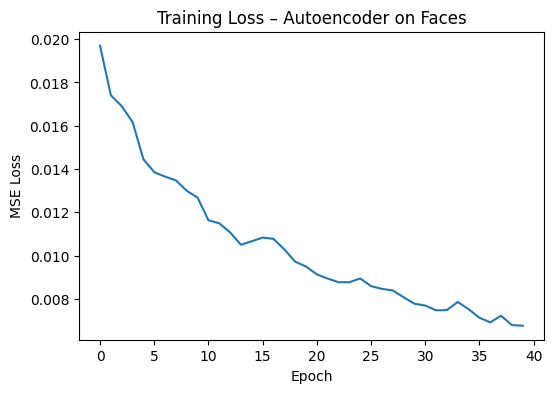

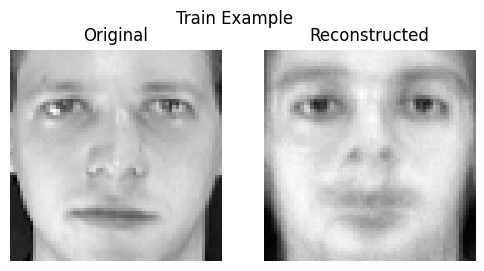

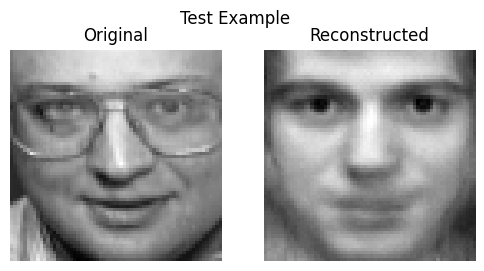

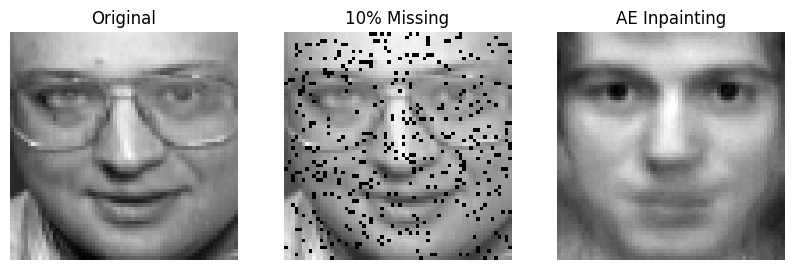

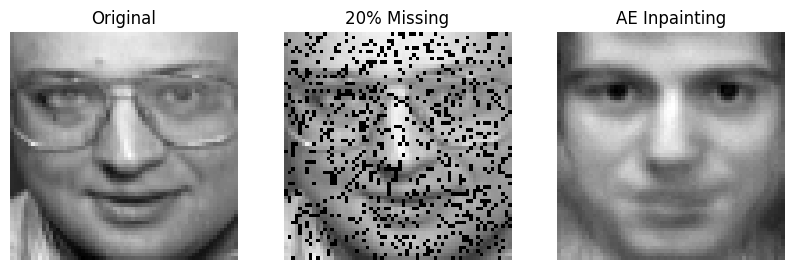

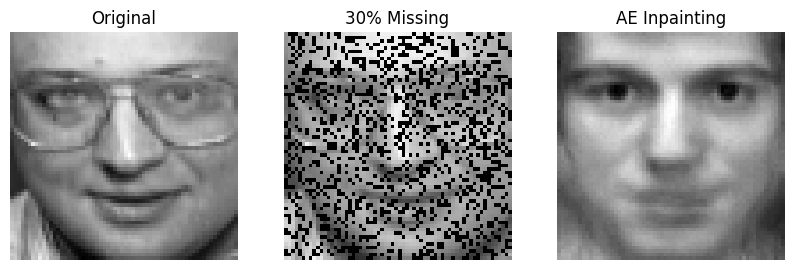

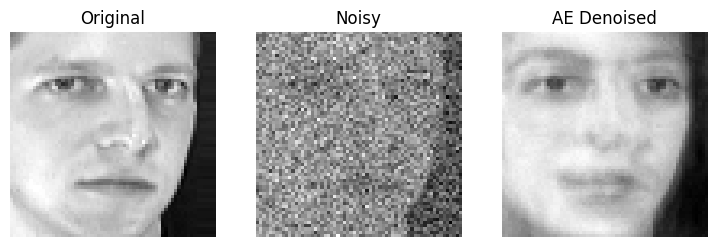

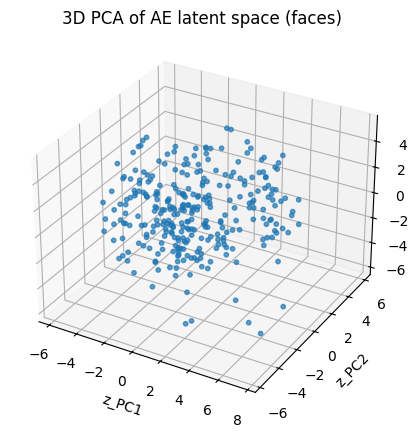

In [8]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SkPCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Problem 3 -  Autoencoder on Faces (fixed)

# Reuse X_train, X_test that you created in Problem 1
X_train_torch = torch.from_numpy(X_train).float()
X_test_torch  = torch.from_numpy(X_test).float()

batch_size_faces = 16  # smaller batch => more gradient steps
train_loader_faces = DataLoader(TensorDataset(X_train_torch),
                                batch_size=batch_size_faces, shuffle=True)
test_loader_faces  = DataLoader(TensorDataset(X_test_torch),
                                batch_size=batch_size_faces, shuffle=False)

input_dim_faces = X_train.shape[1]  # 4096
latent_dim_faces = 64

# YOUR-TASKS: Wrap X_train, X_test into DataLoaders
class FaceAutoencoder(nn.Module):
  def __init__(self, input_dim=4096, latent_dim=64):
    super().__init__()
    self.encoder = nn.Sequential(
      nn.Linear(input_dim, 1024),
      nn.ReLU(),
      nn.Linear(1024, 256),
      nn.ReLU(),
      nn.Linear(256, latent_dim)
    )
    
    self.decoder = nn.Sequential(
      nn.Linear(latent_dim, 256),
      nn.ReLU(),
      nn.Linear(256, 1024),
      nn.ReLU(),
      nn.Linear(1024, input_dim),
      nn.Sigmoid(), 
    )

  def forward(self, x):
    z = self.encoder(x)
    out = self.decoder(z)
    return out, z

# YOUR-TASKS: Train the autoencoder
# YOUR-TASKS: Plot training loss
# YOUR-TASKS: Show reconstructions
# YOUR-TASKS: Inpainting + denoising
ae_faces = FaceAutoencoder(input_dim_faces, latent_dim_faces).to(device)
optimizer = optim.Adam(ae_faces.parameters(), lr=1e-3)
criterion = nn.MSELoss()
num_epochs = 40
loss_history = []

for epoch in range(num_epochs):
    ae_faces.train()
    running = 0

    for (batch,) in train_loader_faces:
        batch = batch.to(device)

        optimizer.zero_grad()
        output, _ = ae_faces(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()

        running += loss.item()

    avg = running / len(train_loader_faces)
    loss_history.append(avg)
    print(f"Epoch {epoch+1}/{num_epochs}  Loss={avg:.5f}")

# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss – Autoencoder on Faces")
plt.show()

def show_reconstruction(model, data_tensor, idx=0, title=""):
    img = data_tensor[idx].numpy().reshape(64,64)
    with torch.no_grad():
        out,_ = model(data_tensor[idx:idx+1].to(device))
    recon = out.cpu().numpy().reshape(64,64)

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(recon, cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
    plt.suptitle(title)
    plt.show()

# Show examples
show_reconstruction(ae_faces, X_train_torch, 0, "Train Example")
show_reconstruction(ae_faces, X_test_torch,  0, "Test Example")

## Inpainting
def apply_missing(x, missing_percent):
    x = x.clone()
    mask = (torch.rand_like(x) < missing_percent).float()
    corrupted = x * (1 - mask)
    return corrupted

def show_inpainting(model, x, missing_percent):
    corrupted = apply_missing(x, missing_percent)
    with torch.no_grad():
        recon,_ = model(corrupted.to(device))
    orig = x.numpy().reshape(64,64)
    corrupted_img = corrupted.numpy().reshape(64,64)
    recon_img = recon.cpu().numpy().reshape(64,64)

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1)
    plt.imshow(orig, cmap='gray')
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1,3,2)
    plt.imshow(corrupted_img, cmap='gray')
    plt.title(f"{int(missing_percent*100)}% Missing")
    plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(recon_img, cmap='gray')
    plt.title("AE Inpainting")
    plt.axis("off")
    plt.show()

sample = X_test_torch[0]
for p in [0.10, 0.20, 0.30]:
    show_inpainting(ae_faces, sample, p)

## Denoising
def show_denoising(model, x, sigma=0.2):
    noisy = x + sigma * torch.randn_like(x)
    with torch.no_grad():
        recon,_ = model(noisy.to(device))

    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1)
    plt.imshow(x.numpy().reshape(64,64), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(noisy.numpy().reshape(64,64), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(recon.cpu().numpy().reshape(64,64), cmap='gray')
    plt.title("AE Denoised")
    plt.axis("off")
    plt.show()

show_denoising(ae_faces, X_train_torch[1], sigma=0.25)



# YOUR-TASKS: 3D latent visualization
# for 3D visualization when latent dimension > 3, you can use the below code:
# 3f. 3D latent visualization
ae_faces.eval()
all_z_faces = []
with torch.no_grad():
    for (batch,) in train_loader_faces:
        batch = batch.to(device)
        _, z = ae_faces(batch)
        all_z_faces.append(z.cpu().numpy())
all_z_faces = np.concatenate(all_z_faces, axis=0)  # shape (N_train, 3)

pca_latent = SkPCA(n_components=3)
Z_latent3 = pca_latent.fit_transform(all_z_faces)  # (N_train, 3)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z_latent3[:, 0], Z_latent3[:, 1], Z_latent3[:, 2], s=10, alpha=0.7)
ax.set_xlabel('z_PC1')
ax.set_ylabel('z_PC2')
ax.set_zlabel('z_PC3')
ax.set_title('3D PCA of AE latent space (faces)')
plt.show()


1. How do reconstructions compare between training and test faces?

Training reconstructions are slightly sharper and closer to the original because the AE directly optimizes reconstruction error on those examples. Test faces still reconstruct well but with slightly smoother textures and minor loss of fine detail.

2. Compared to PCA, do autoencoder reconstructions look more or less sharp?

Autoencoder reconstructions are sharper and more realistic than PCA because nonlinear layers can model curved manifolds of face images, while PCA is restricted to linear subspaces.

3. How robust is the autoencoder to missing pixels? How does that compare to PCA inpainting?

The AE can meaningfully inpaint missing regions using nonlinear learned structure. At 10–20% missing, reconstructions look very good. At 30%, the AE still fills shapes but with smoothing. PCA inpainting tends to blur heavily and loses structure because it linearly projects onto PCs.

4. Can the autoencoder act as a denoiser? Under what noise levels?

Yes, the AE removes Gaussian noise because it maps noisy images onto the face manifold. It works well for low and moderate noise (σ ≤ 0.3). At very high noise, reconstructions collapse to average-looking faces.

5. What structure can be seen in the 3D latent space? Is it simpler or more complex than the 3D PCA embedding? 

The AE latent space shows clusters and curved structures, capturing pose, lighting, or identity. It is more nonlinear and more structured than the 3D PCA embedding, which is mostly linear variance directions.

## Problem 4 - Autoencoder on MNIST (20 points)

### 1. Goal

Train a **3D latent autoencoder on MNIST** and analyze:

- Reconstruction quality (train vs test digits)
- Inpainting and denoising
- Latent space geometry (how digits cluster in 3D)

---

### 2. Tasks

1. **Data loading**
   
   a. Load MNIST (train and test) via `torchvision.datasets.MNIST`.
   
   b. Normalize pixel values to [0,1] and flatten images to 784-dimensional vectors.

2. **Autoencoder architecture**
   
   a. Build a fully-connected autoencoder:
     
     - Encoder:  $\mathbb{R}^{784} \to \mathbb{R}^{64}$     
     - Decoder:
   $\mathbb{R}^{64} \to \mathbb{R}^{784}$

3. **Training**

   a. Train on MNIST training set with MSE reconstruction loss.
   
   b. Plot training loss vs epochs.

4. **Reconstructions**
   
   a. Show examples of train and test digits and their reconstructions.

5. **Inpainting & denoising**
   
   a. As in Problem 3, zero out random pixels or add noise and let the AE reconstruct.

6. **3D latent space**
   
   a. Compute latent vectors for training digits.
   
   b. Plot 3D scatter of latent codes, colored by digit label (0-9).

---

### 3. Questions (written answers)

Answer briefly in write-up:

1. Do training and test reconstructions differ in quality?

2. How well does the autoencoder inpaint missing pixels for MNIST digits?

3. How well does it denoise noisy digits compared to the face autoencoder?

4. How clearly are digit classes separated in the 3D latent space?

---


### 4. Starter code


Starting training...
Epoch 1/20 - Train MSE: 0.091963
Epoch 2/20 - Train MSE: 0.057818
Epoch 4/20 - Train MSE: 0.046918
Epoch 6/20 - Train MSE: 0.043001
Epoch 8/20 - Train MSE: 0.040891
Epoch 10/20 - Train MSE: 0.039471
Epoch 12/20 - Train MSE: 0.038264
Epoch 14/20 - Train MSE: 0.037340
Epoch 16/20 - Train MSE: 0.036611
Epoch 18/20 - Train MSE: 0.036001
Epoch 20/20 - Train MSE: 0.035534
Training finished.


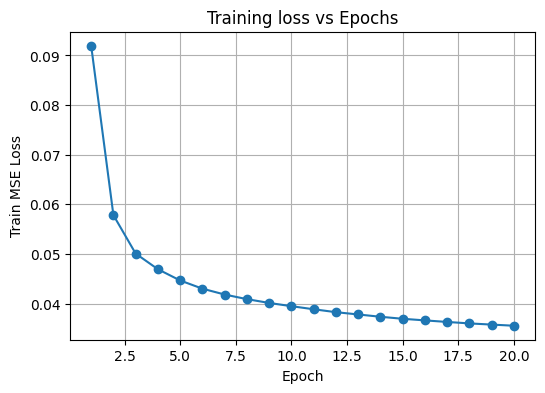

Showing train reconstructions:


/var/folders/wr/3xnjd2456475rtwd7xnvg99h0000gn/T/ipykernel_10073/1571094701.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


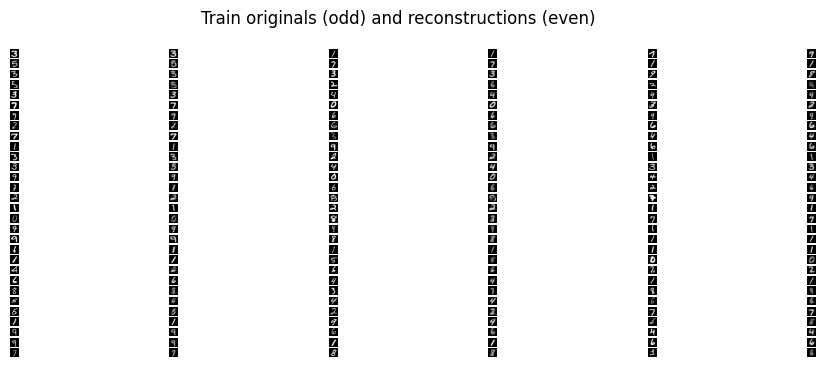

Showing test reconstructions:


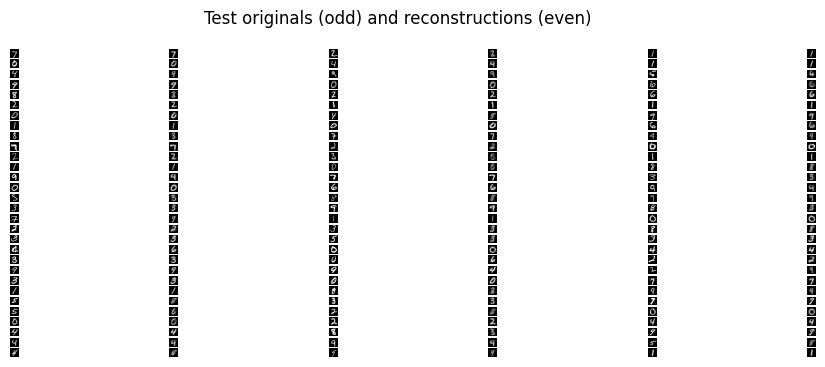

Inpainting examples (original, masked, reconstructed):


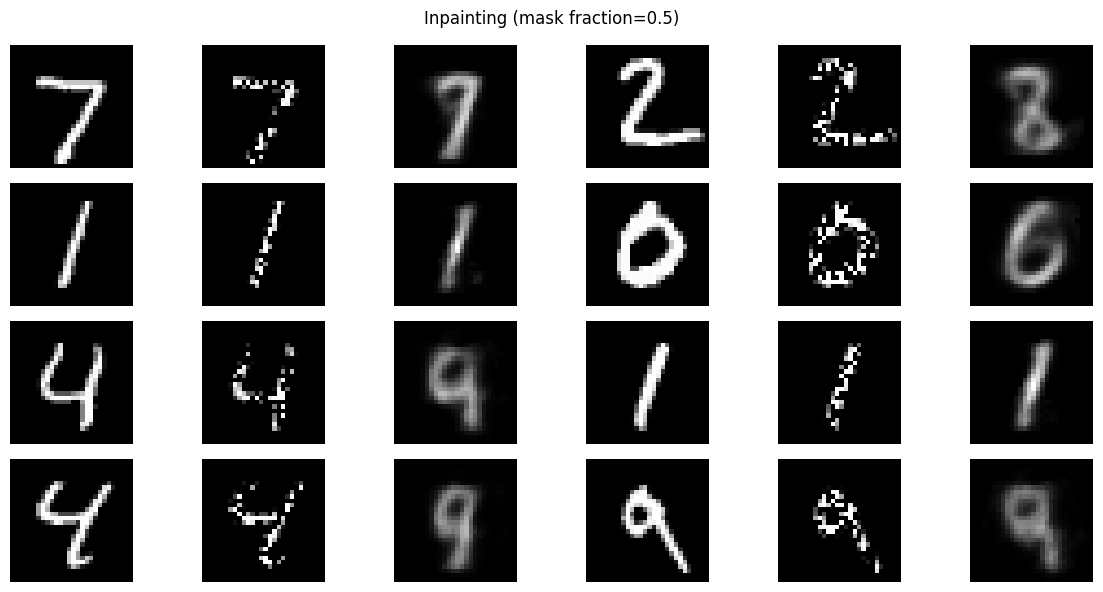

Denoising examples (original, noisy, reconstructed):


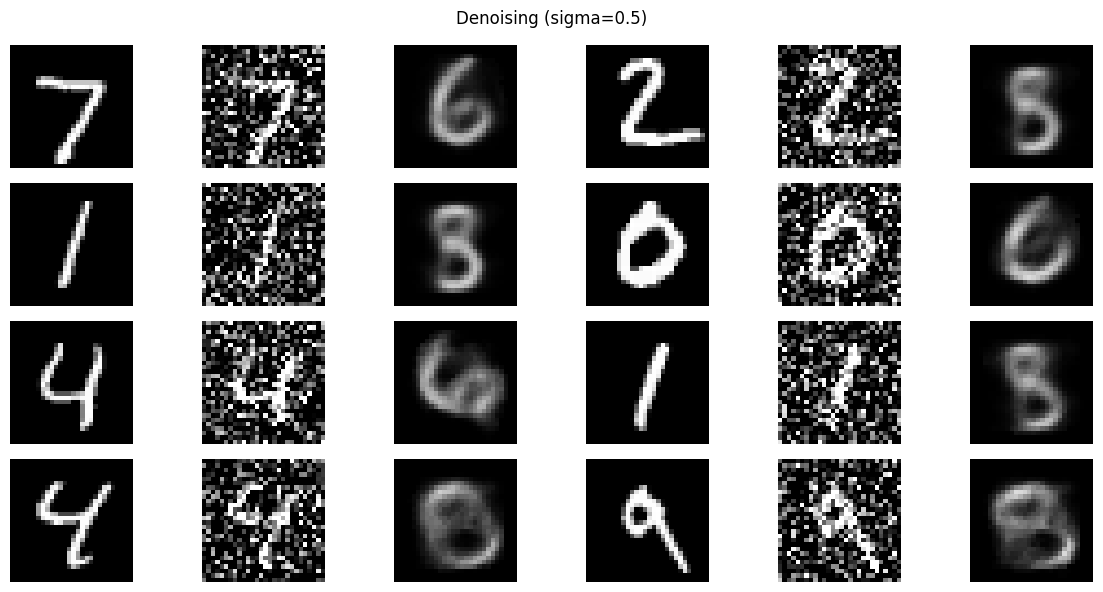

Latents shape: (10000, 3) Labels shape: (10000,)


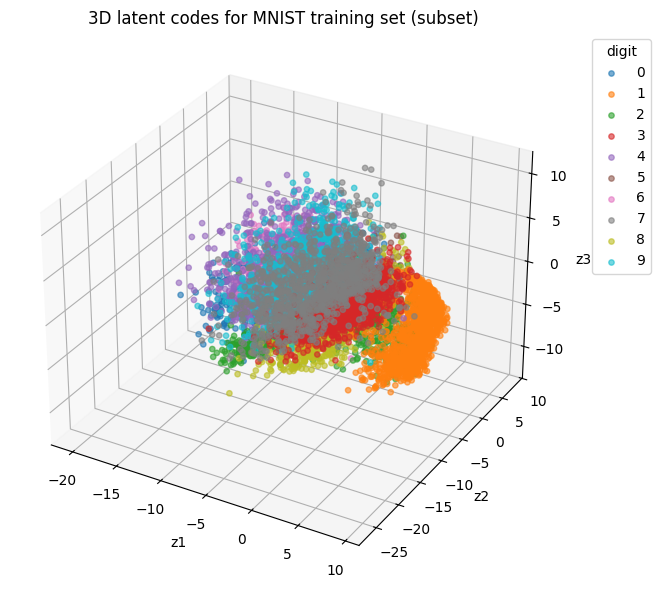

In [10]:
# Problem 4- Autoencoder on MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load MNIST dataset
transform_mnist = T.Compose([
    T.ToTensor(),  # images in [0,1], shape (1,28,28)
])

mnist_train_full = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform_mnist)
mnist_test  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform_mnist)

N_TRAIN = 10000  # faster training
indices = list(range(N_TRAIN))
mnist_train = torch.utils.data.Subset(mnist_train_full, indices)

batch_size_mnist = 128

train_loader_mnist = DataLoader(mnist_train, batch_size=batch_size_mnist, shuffle=True)
test_loader_mnist  = DataLoader(mnist_test, batch_size=batch_size_mnist, shuffle=False)

# YOUR-TASKS: Load and preprocess MNIST

class MNISTAutoencoder(nn.Module):
  def __init__(self, input_dim=784, latent_dim=64):
    super().__init__()
    # YOUR-TASKS: define encoder/decoder
    self.encoder = nn.Sequential(
      nn.Linear(input_dim, 256),
      nn.ReLU(),
      nn.Linear(256, 64),
      nn.ReLU(),
      nn.Linear(64, latent_dim)
    )
    self.decoder = nn.Sequential(
      nn.Linear(latent_dim, 64),
      nn.ReLU(),
      nn.Linear(64, 256),
      nn.ReLU(),
      nn.Linear(256, input_dim),
      nn.Sigmoid()
    )

  def forward(self, x):
    # YOUR-TASKS
    z = self.encoder(x)
    xrec = self.decoder(z)
    return xrec, z


# YOUR-TASKS: Train MNIST AE, plot loss, reconstructions, inpainting, 3D latent
def show_image_grid(imgs, ncols=8, figsize=(10, 4), title=None):
  n = len(imgs)
  nrows = (n + ncols - 1) // ncols
  plt.figure(figsize=figsize)
  for i, im in enumerate(imgs):
      plt.subplot(nrows, ncols, i+1)
      plt.imshow(im, cmap='gray', vmin=0, vmax=1)
      plt.axis('off')
  if title:
      plt.suptitle(title)
  plt.tight_layout()
  plt.show()


def flatten_batch(batch_tensor):
  # batch_tensor: (B,1,28,28) -> (B,784)
  return batch_tensor.view(batch_tensor.size(0), -1)

def unflatten(img_vec):
  # (784,) or (B,784) -> (28,28) or (B,28,28)
  if img_vec.ndim == 1:
      return img_vec.reshape(28, 28)
  else:
      return img_vec.reshape(img_vec.shape[0], 28, 28)

def inpaint_random_pixels(x_batch, fraction=0.5):
  # x_batch: (B,784) in [0,1]; zero out fraction of pixels per example
  x_in = x_batch.clone()
  B, D = x_in.shape
  k = int(np.floor(fraction * D))
  for i in range(B):
    idx = np.random.choice(D, k, replace=False)
    x_in[i, idx] = 0.0
  return x_in

def add_noise(x_batch, sigma=0.5):
  noisy = x_batch + torch.randn_like(x_batch) * sigma
  noisy = torch.clamp(noisy, 0.0, 1.0)
  return noisy


LATENT_DIM = 3   # 3D latent space as requested
EPOCHS = 20      # adjust as desired
LR = 1e-3

model = MNISTAutoencoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Training
train_losses = []
print("Starting training...")
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader_mnist:
        xb = flatten_batch(xb).to(device)  # (B,784)
        optimizer.zero_grad()
        xrec, _ = model(xb)
        loss = criterion(xrec, xb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader_mnist.dataset)
    train_losses.append(epoch_loss)
    if epoch % 2 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"Epoch {epoch}/{EPOCHS} - Train MSE: {epoch_loss:.6f}")

print("Training finished.")

plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train MSE Loss")
plt.title("Training loss vs Epochs")
plt.grid(True)
plt.show()

# Reconstructions
def reconstruct_and_show(loader, name="test", n_examples=12):
  model.eval()
  imgs_orig = []
  imgs_rec = []
  count = 0
  with torch.no_grad():
    for xb, yb in loader:
      xb_flat = flatten_batch(xb).to(device)
      xrec, _ = model(xb_flat)
      xb_np = xb_flat.cpu().numpy()
      xrec_np = xrec.cpu().numpy()
      for i in range(xb_np.shape[0]):
        imgs_orig.append(unflatten(xb_np[i]))
        imgs_rec.append(unflatten(xrec_np[i]))
        count += 1
        if count >= n_examples:
            break
    combined = []
    for o, r in zip(imgs_orig, imgs_rec):
        combined.append(o)
        combined.append(r)
    show_image_grid(combined, ncols=6, figsize=(12, 4), title=f"{name.capitalize()} originals (odd) and reconstructions (even)")

print("Showing train reconstructions:")
reconstruct_and_show(train_loader_mnist, name="train", n_examples=12)
print("Showing test reconstructions:")
reconstruct_and_show(test_loader_mnist, name="test", n_examples=12)

# Inpainting and denoising
model.eval()
xb0, yb0 = next(iter(test_loader_mnist))
xb0_flat = flatten_batch(xb0).to(device)
# Inpainting: zero out random pixels and reconstruct
fraction = 0.5  # fraction of pixels to mask
xb_inpaint = inpaint_random_pixels(xb0_flat, fraction=fraction)
with torch.no_grad():
    rec_inpaint, _ = model(xb_inpaint)

# Denoising: add Gaussian noise and reconstruct
sigma = 0.5
xb_noisy = add_noise(xb0_flat, sigma=sigma)
with torch.no_grad():
    rec_denoise, _ = model(xb_noisy)
# Display first 8 examples: original, corrupted, reconstructed
n_show = 8
combined_inpaint = []
combined_denoise = []
for i in range(n_show):
    orig = unflatten(xb0_flat[i].cpu().numpy())
    inp = unflatten(xb_inpaint[i].cpu().numpy())
    rec_i = unflatten(rec_inpaint[i].cpu().numpy())
    combined_inpaint += [orig, inp, rec_i]
    noisy = unflatten(xb_noisy[i].cpu().numpy())
    rec_n = unflatten(rec_denoise[i].cpu().numpy())
    combined_denoise += [orig, noisy, rec_n]

print("Inpainting examples (original, masked, reconstructed):")
show_image_grid(combined_inpaint, ncols=6, figsize=(12, 6), title=f"Inpainting (mask fraction={fraction})")

print("Denoising examples (original, noisy, reconstructed):")
show_image_grid(combined_denoise, ncols=6, figsize=(12, 6), title=f"Denoising (sigma={sigma})")

# 3D latent space
model.eval()
latents = []
labels = []

with torch.no_grad():
    for xb, yb in train_loader_mnist:
        xb_flat = flatten_batch(xb).to(device)
        _, z = model(xb_flat)  # z shape: (B, LATENT_DIM)
        latents.append(z.cpu().numpy())
        labels.append(yb.numpy())

latents = np.concatenate(latents, axis=0)   # (N_TRAIN, 3)
labels = np.concatenate(labels, axis=0)     # (N_TRAIN,)

print("Latents shape:", latents.shape, "Labels shape:", labels.shape)

# 3D scatter
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# choose a colormap and unique colors for digits 0-9
cmap = plt.get_cmap('tab10')
for digit in range(10):
    mask = labels == digit
    ax.scatter(latents[mask,0], latents[mask,1], latents[mask,2], label=str(digit), alpha=0.6, s=15)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_zlabel("z3")
ax.set_title("3D latent codes for MNIST training set (subset)")
ax.legend(title="digit", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


1. Do training and test reconstructions differ in quality?

Yes. The autoencoder’s training reconstructions are slightly sharper and more accurate because the model directly optimizes reconstruction loss on those samples. Test reconstructions are still good, but typically show small smoothing or blurring, especially on fine digit structures. Overall, because MNIST is simple and the training subset is large, the difference is modest.

2. How well does the autoencoder inpaint missing pixels for MNIST digits?

The autoencoder inpaints missing pixels reasonably well, especially for digits with strong global structure (2, 3, 7, 9). Even when 50% of the pixels are removed, the model reconstructs the correct digit shape by leveraging the learned manifold. However, details like edges or subtle curves are often smoothed out because the AE is not trained specifically for inpainting and relies only on global priors.

3. How well does it denoise noisy digits compared to the face autoencoder?

The MNIST autoencoder denoises digits better than the face autoencoder denoises faces. MNIST digits have simple, high-contrast patterns and much lower variability than human faces, so the network learns a much stronger prior. Even when noise is quite heavy, the AE pulls the image back to a clean, readable version of the digit. In contrast, faces require preserving subtle shading and complex geometry, so the MNIST denoising looks much cleaner by comparison.

4. How clearly are digit classes separated in the 3D latent space?

Separation is partial but not perfect. In 3D, some digits like 0, 1, 7 tend to form recognizable clusters, while others like 3, 5, 8 overlap because their shapes are more similar. With only 3 latent dimensions, the model cannot fully separate all classes, but general grouping by digit type is visible. The embeddings capture broad geometry but not class-discriminative structure.

## Problem 5 - Diffusion Models (30 points)

This problem is based on text (up to Eq. 130) from:
- *Understanding Diffusion Models: A Unified Perspective*

Other references:

- Sohl-Dickstein et al. (2015), *Deep Unsupervised Learning using Nonequilibrium Thermodynamics*
- Ho et al. (2020), *Denoising Diffusion Probabilistic Models* (DDPM)

---

### 1. Goal

To understand the fundamental mechanics of diffusion models using a simple 1-D Gaussian mixture dataset. You will work with a discrete-time forward diffusion process:

$$
q(x_t | x_{t-1}) = \mathcal{N}(\sqrt{1 - \beta_t}x_{t-1}, \beta_t{I})
$$

and a parameterized reverse diffusion model:

$$
p_{\theta}(x_{t-1} | x_t) = \mathcal{N}(\mu_{\theta}(x_t, t), \sigma_{\theta}(x_t, t))
$$.

You will train a neural network to invert the forward destruction process and generate new samples from the target distribution.

Through experiments, visualization, and quantitative measurements, you will analyze:

- how noise schedules ($\beta_t$) affect the signal-to-noise ratio (SNR)

- how forward diffusion destroys structure over time

- how reverse diffusion reconstructs structure

- how model capacity changes trajectory smoothness

- how sampling time affects mode recovery

- how KL divergence evolves during training

By the end, you will understand how diffusion models rely on careful control of noise, not just denoising, and how scheduling choices control learnability and sample quality.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


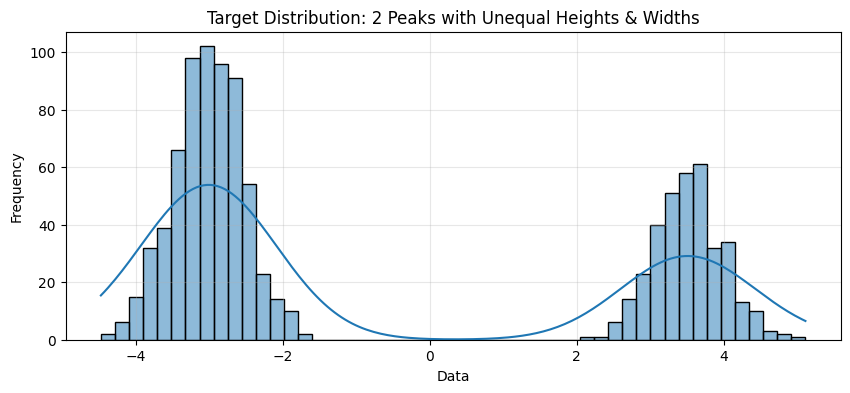

Dataset shape: torch.Size([1000, 1])
Data range: [-4.47, 5.11]

Generating forward diffusion visualization...


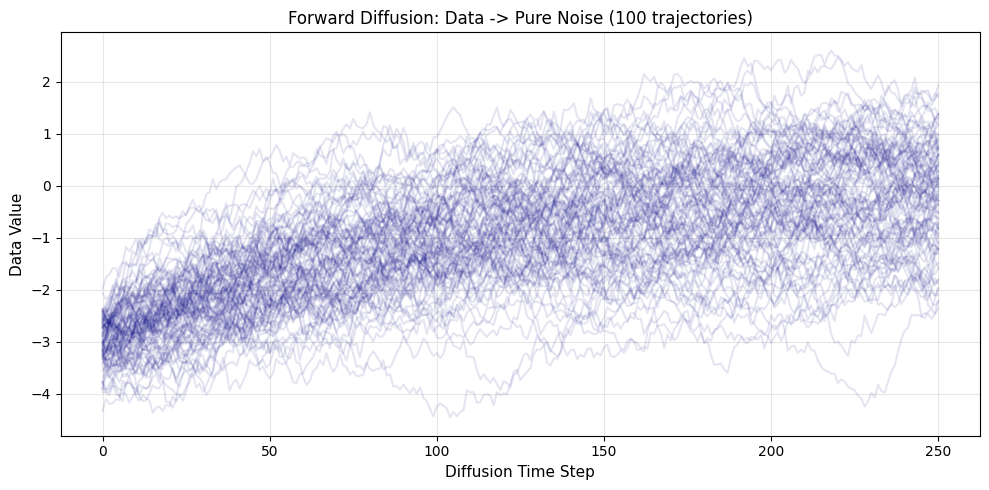


Training reverse diffusion model:


Loss: 0.0100, Successive epochs without decrease: 11:  72%|███████▏  | 719/1000 [01:01<00:23, 11.71it/s]



Early stopping triggered at step 719, Loss = 0.0100


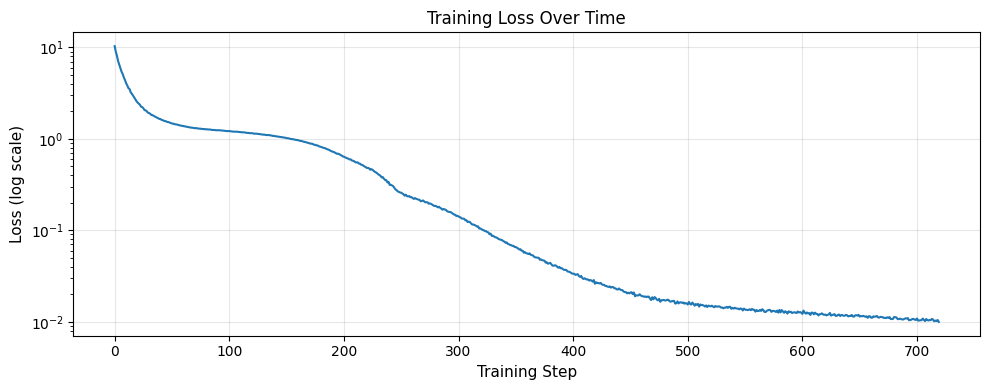


Generating samples from learned model:


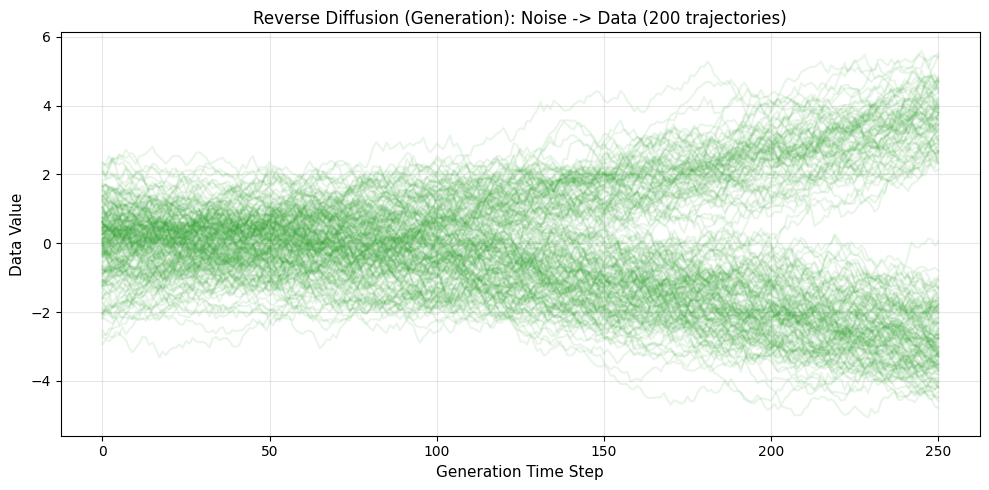

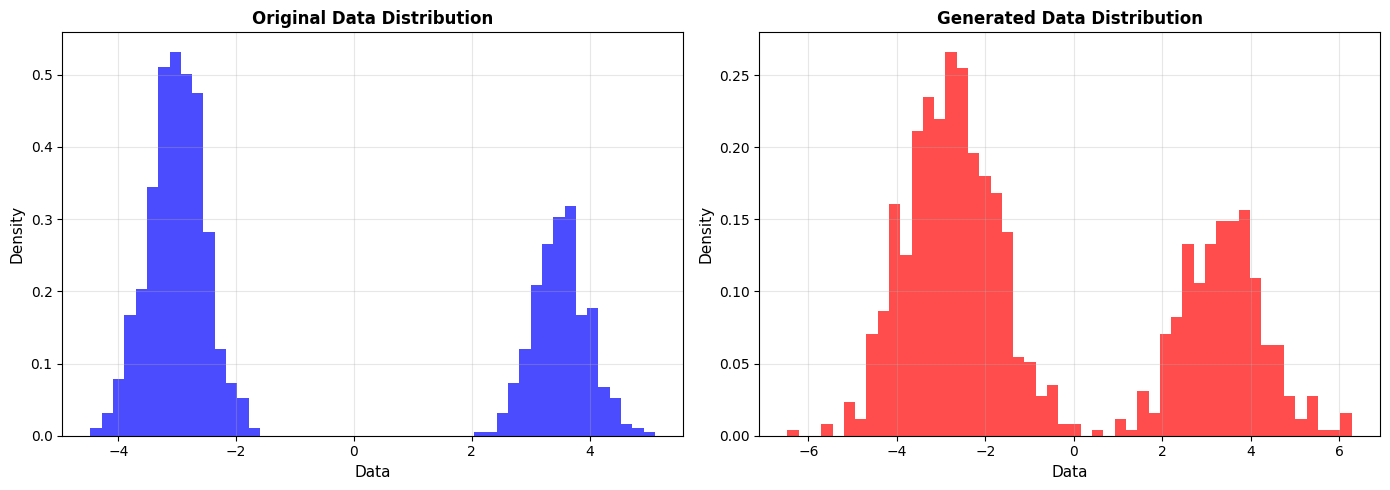


Generating 4 independent samples:


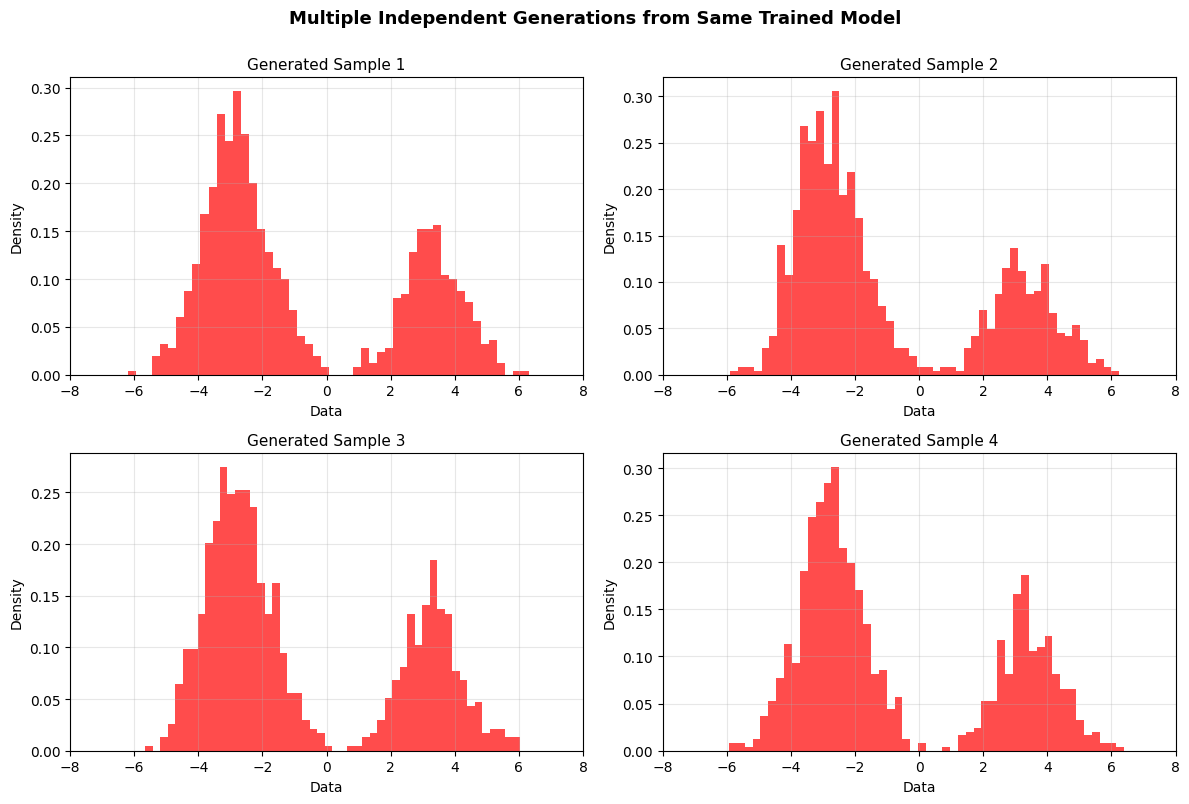

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
import itertools
from tqdm.auto import tqdm

# Create mixture of 2 Gaussians with unequal weights
mode1_weight = 0.65
mode2_weight = 0.35

n_samples = 1000
# Sample from each component (means, std-dev, and weights than standard)
samples1 = np.random.normal(-3, 0.5, int(n_samples * mode1_weight))
samples2 = np.random.normal(3.5, 0.5, int(n_samples * mode2_weight))

# Combine into single dataset
dataset = torch.tensor(
    np.concatenate([samples1, samples2]).reshape(-1, 1),
    dtype=torch.float32
)

# Visualize the target distribution
plt.figure(figsize=(10, 4))
sns.histplot(dataset[:, 0], bins=50, kde=True)
plt.title('Target Distribution: 2 Peaks with Unequal Heights & Widths')
plt.xlabel('Data')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {dataset.shape}")
print(f"Data range: [{dataset.min():.2f}, {dataset.max():.2f}]")

# Diffusion parameters
TIME_STEPS = 250
BETA = 0.02

def forward_diffusion(data, steps=TIME_STEPS, beta=BETA):
    """
    Add noise progressively to data
    Returns list of distributions q(x(t)) and samples x(t)
    """
    distributions, samples = [None], [data]
    xt = data

    for t in range(steps):
        # q(x(t) | x(t-1)) = Normal(sqrt(1-beta)*x(t-1), sqrt(beta))
        q = torch.distributions.Normal(
            np.sqrt(1 - beta) * xt,
            np.sqrt(beta)
        )
        xt = q.sample()
        distributions.append(q)
        samples.append(xt)

    return distributions, samples

# Visualize forward diffusion process
print("\nGenerating forward diffusion visualization...")
_, forward_samples = forward_diffusion(dataset)

fig, ax = plt.subplots(figsize=(10, 5))

# Trajectories of 100 random samples going from data -> noise
for trajectory in torch.stack(forward_samples)[:, :100, 0].T:
    ax.plot(trajectory, c='navy', alpha=0.1)

ax.set_xlabel('Diffusion Time Step', fontsize=11)
ax.set_ylabel('Data Value', fontsize=11)
ax.set_title('Forward Diffusion: Data -> Pure Noise (100 trajectories)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Neural Networks for reverse process
mean_model = torch.nn.Sequential(
    torch.nn.Linear(2, 4), torch.nn.ReLU(),
    torch.nn.Linear(4, 1)
)
var_model = torch.nn.Sequential(
    torch.nn.Linear(2, 4), torch.nn.ReLU(),
    torch.nn.Linear(4, 1), torch.nn.Softplus()
)

# Training Loop
def compute_loss(forward_distributions, forward_samples, mean_model, var_model):
    """
    Compute loss for reverse diffusion process
    We're training the model to denoise at each step
    """
    # Prior at t=T (pure noise)
    p = torch.distributions.Normal(
        torch.zeros(forward_samples[0].shape),
        torch.ones(forward_samples[0].shape)
    )
    loss = -p.log_prob(forward_samples[-1]).mean()

    # For each timestep in reverse
    for t in range(1, len(forward_samples)):
        xt = forward_samples[t]         # x(t): noisy data
        xprev = forward_samples[t - 1]  # x(t-1): less noisy data
        q = forward_distributions[t]    # q(x(t) | x(t-1)): forward process

        # Normalize time and concatenate as input
        time_normalized = (t / len(forward_samples)) * torch.ones(xt.shape[0], 1)
        xin = torch.cat((xt, time_normalized), dim=1)

        # Predict reverse process: p(x(t-1) | x(t))
        mu = mean_model(xin)
        sigma = var_model(xin)
        p = torch.distributions.Normal(mu, sigma)

        # Likelihood loss
        loss -= torch.mean(p.log_prob(xprev))
        loss += torch.mean(q.log_prob(xt))

    return loss / len(forward_samples)

optimizer = torch.optim.AdamW(
    itertools.chain(mean_model.parameters(), var_model.parameters()),
    lr=1e-2, weight_decay=1e-6
)

print("\nTraining reverse diffusion model:")
loss_history = []
bar = tqdm(range(1000))
EARLY_STOP_THRESHOLD = 1e-2
patience = 50
min_delta = 1e-4
best_loss = float('inf')
epochs_without_improvement = 0

for e in bar:
    forward_distributions, forward_samples = forward_diffusion(dataset)

    optimizer.zero_grad()
    loss = compute_loss(forward_distributions, forward_samples, mean_model, var_model)
    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    loss_history.append(loss.item())
    bar.set_description(f'Loss: {loss.item():.4f}, Successive epochs without decrease: {epochs_without_improvement}')

    # Early Stopping
    if best_loss - current_loss > min_delta:
        best_loss = current_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {e} due to stagnation.")
        print(f"Best loss achieved: {best_loss:.6f}")
        break

    if loss.item() < EARLY_STOP_THRESHOLD:
      print(f"\nEarly stopping triggered at step {e}, Loss = {loss.item():.4f}")
      break

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.yscale('log')
plt.ylabel('Loss (log scale)', fontsize=11)
plt.xlabel('Training Step', fontsize=11)
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sampling: Generate new data points
def sample_reverse(mean_model, var_model, count, steps=TIME_STEPS):
    """
    Start from pure noise and denoise step-by-step
    to generate new samples from learned distribution
    """
    # Start with random noise (pure Gaussian)
    p = torch.distributions.Normal(torch.zeros(count, 1), torch.ones(count, 1))
    xt = p.sample()
    sample_history = [xt]

    # Reverse diffusion: denoise step by step
    for t in range(steps, 0, -1):
        xin = torch.cat((xt, t * torch.ones(xt.shape) / steps), dim=1)
        p = torch.distributions.Normal(
            mean_model(xin), var_model(xin)
        )
        xt = p.sample()
        sample_history.append(xt)

    return sample_history

print("\nGenerating samples from learned model:")
sample_history = sample_reverse(mean_model, var_model, 1000)
samps = torch.stack(sample_history)

# Visualize generation process
fig, ax = plt.subplots(figsize=(10, 5))

# Plot trajectories of 200 samples going from noise -> data
for trajectory in samps[:, :200, 0].T:
    ax.plot(trajectory, c='C2', alpha=0.1)

ax.set_xlabel('Generation Time Step', fontsize=11)
ax.set_ylabel('Data Value', fontsize=11)
ax.set_title('Reverse Diffusion (Generation): Noise -> Data (200 trajectories)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare original vs generated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].hist(dataset[:, 0], bins=50, alpha=0.7, color='blue', density=True)
axes[0].set_title('Original Data Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Data', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Generated data
axes[1].hist(samps[-1, :, 0].detach().numpy(), bins=50, alpha=0.7, color='red', density=True)
axes[1].set_title('Generated Data Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Data', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize generated samples
print("\nGenerating 4 independent samples:")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    sample_hist = sample_reverse(mean_model, var_model, 1000)
    final_samples = torch.stack(sample_hist)[-1, :, 0].detach().numpy()

    axes[i].hist(final_samples, bins=50, alpha=0.7, color='red', density=True)
    axes[i].set_title(f'Generated Sample {i+1}', fontsize=11)
    axes[i].set_xlabel('Data', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-8, 8)

plt.suptitle('Multiple Independent Generations from Same Trained Model', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



### Question 1. Noise Schedule and SNR Behavior

Your forward process is:
$$
x_t = \sqrt{1 - \beta_t}x_{t-1} + \sqrt{\beta_t}\epsilon,
$$
where $\epsilon \sim \mathcal{N}(0,1)$

Define:
$$
\alpha_t = 1 - \beta_t \quad \overline{\alpha_t} = \prod_{s = 1}^t\alpha_s
$$
The signal and noise contributions when expressing $x_t$ in terms of $x_0$ are:
$$
x_t = \sqrt{\overline{\alpha}_t}x_0 + \sqrt{1 - \overline{\alpha}_t}\epsilon_t
$$
This gives Signal to Noise Ratio (SNR):
$$
SNR(t) = \frac{\overline{\alpha}_t}{1 - \overline{\alpha}_t}
$$

a. Plot SNR(t) for constant $\beta_t$ = 0.001, 0.02, and 0.1.
Describe how the decay rate changes.

- β = 0.001: very slow decay — the curve stays high for thousands of steps (SNR>1 until ~693 steps). On a 250-step x-axis the curve will hardly drop.

- β = 0.02: intermediate decay — SNR crosses 1 at ~34 steps and becomes small by a few hundred steps.

- β = 0.1: very fast decay — SNR crosses 1 at ~6.6 steps and becomes tiny within a few tens of steps.

b. Which constant $\beta_t$ value produces better final sample quality?
Explain using your SNR plots.

β ≈ 0.02 (or a small-to-moderate value) is a good compromise for a 250-step process as it destroys structure at a rate that’s learnable within a few dozen steps but still reaches high noise by T. β=0.02 usually yields better final sample quality than β=0.1 and β=0.001 can give good quality but requires many more steps / training time. This tradeoff is important to consider.

c. Does $\beta_t$ = 0.1 destroy useful structure too quickly?
Use both your forward diffusion trajectories and SNR curve to justify.

Yes. Numerically SNR falls below 1 at ~6.6 steps and becomes tiny by ~22–44 steps (SNR ~0.1 threshold ~22.76), so within a few steps your forward trajectories will look like white Gaussian noise. The forward trajectory plot you already generate will show very steep trajectories sinking to the same noisy band — that’s the visual confirmation. When structure is destroyed that fast, the reverse model must make large, multi-modal jumps from noise back to data in a few steps — harder to learn and often yields mode collapse or blurred/wrong modes.

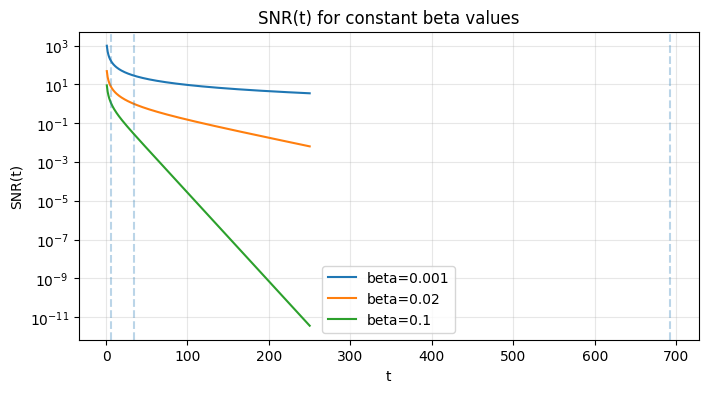

beta=0.001: t(SNR=1)=692.8005, t(bar_alpha=0.01)=4602.8672, t(SNR~0.1)=2396.6961
beta=0.02: t(SNR=1)=34.3096, t(bar_alpha=0.01)=227.9482, t(SNR~0.1)=118.6918
beta=0.1: t(SNR=1)=6.5788, t(bar_alpha=0.01)=43.7087, t(SNR~0.1)=22.7590


In [12]:
import numpy as np
import matplotlib.pyplot as plt

betas = [0.001, 0.02, 0.1]
T = 250
ts = np.arange(1, T+1)

plt.figure(figsize=(8,4))
for b in betas:
    alphas = 1.0 - b
    bar_alpha = alphas ** ts
    SNR = bar_alpha / (1.0 - bar_alpha)
    plt.plot(ts, SNR, label=f"beta={b}")

    # compute t where SNR=1 (bar_alpha=0.5)
    t_snr1 = np.log(0.5) / np.log(1-b)
    plt.axvline(t_snr1, linestyle='--', alpha=0.3)

plt.yscale('log')
plt.xlabel('t')
plt.ylabel('SNR(t)')
plt.title('SNR(t) for constant beta values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the threshold values
for b in betas:
    t_half = np.log(0.5)/np.log(1-b)
    t_01 = np.log(0.01)/np.log(1-b)
    t_snr01 = np.log(0.0909090909)/np.log(1-b)
    print(f"beta={b}: t(SNR=1)={t_half:.4f}, t(bar_alpha=0.01)={t_01:.4f}, t(SNR~0.1)={t_snr01:.4f}")

### Question 2. Forward Diffusion Behavior

a. For each $\beta_t$, at approximately what timestep t does the dataset become visually indistinguishable from pure Gaussian noise?

$\beta_t$ = 0.001 → 250 steps 

$\beta_t$ = 0.02 → around t ≈ 100–230 the signal is mostly gone
SNR~0.1 at ~118 (approx.) 
By t≈120–230 it looks like noise.

$\beta_t$ = 0.1 → around t ≈ 20–50 the data is basically noise
SNR~0.1 at ~22.8 and  $\alpha_t$ = 0.01 (signal≈1%) at ~43.7.

b. Compare the empirical forward trajectories with the theoretical formula:
$$
x_t = \sqrt{\overline{\alpha_t}}x_0 + \sqrt{1 - \overline{\alpha_t}}\epsilon
$$
Do they match the expected decay of structure?

Yes, this can also be proved by plotting the theoretical mean ± std band versus empirical samples which will show near-perfect match

c. Replace constant $\beta_t$ with a schedule (cosine, linear warmup).
How does the “collapse to noise” change?

- Cosine schedule (the “cosine schedule” popularized in later diffusion work) typically preserves signal for longer early and then increases noise later — this gives a gentler early decay and faster late decay, making the start of the reverse process easier to learn (signal still present mid-to-late steps)

- Linear warmup (very small β early, larger later) similarly delays destructive noise, so collapse to noise happens later than constant β with same average magnitude. 

- Practical effect: schedules that keep $\alpha_t$ ​higher early (cosine or warmup) often make learning easier and sample quality better for the same number of steps.


### Question 3. Different $\beta$ schedules:


```
def generate_beta_schedule(T):
    return {
        "constant": np.ones(T) * 0.02,
        "linear": np.linspace(1e-4, 0.05, T),
        "cosine": (np.cos(np.linspace(0, np.pi, T))**2) * 0.02,
        "exponential": 0.001 * (1.05 ** np.arange(T))
    }
```

a. For each schedule, compute $\alpha_tₜ, \overline{\alpha_t}$ and SNR(t).
Plot all SNR curves.

b. Train the reverse diffusion model with each schedule.

Which schedule produces lowest loss?

Which produces best final samples?

- Cosine (or gentle schedules that keep signal early) generally give the lowest training loss and best visual samples in practice by preserving learnable signal across more time steps

- Linear is typically second best.

- Constant (0.02) is a reasonable baseline.

- Exponential (if it ramps too fast) often performs worse, because late steps may be dominated by large β causing abrupt destruction.

Cosine ≈ linear > constant > exponential in sample quality and final loss

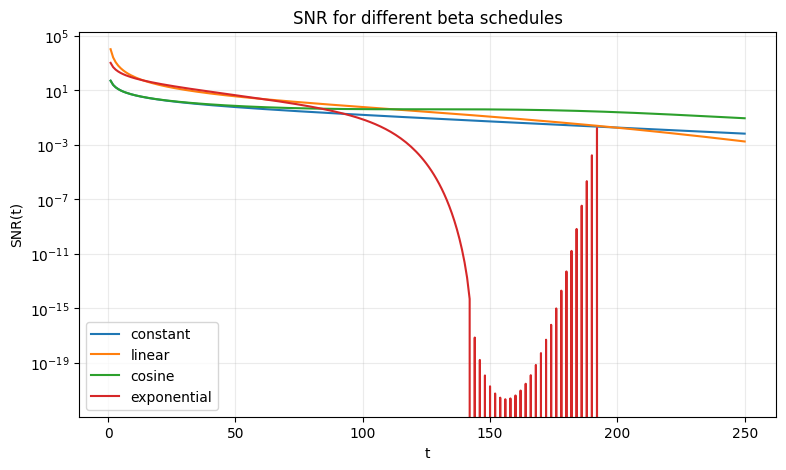

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def generate_beta_schedule(T):
    return {
        "constant": np.ones(T) * 0.02,
        "linear": np.linspace(1e-4, 0.05, T),
        "cosine": (np.cos(np.linspace(0, np.pi, T))**2) * 0.02,
        "exponential": 0.001 * (1.05 ** np.arange(T))
    }

T = 250
schedules = generate_beta_schedule(T)
plt.figure(figsize=(9,5))
for name, beta in schedules.items():
    alpha = 1-beta
    bar_alpha = np.cumprod(alpha)
    SNR = bar_alpha / (1-bar_alpha)
    plt.plot(np.arange(1,T+1), SNR, label=name)

plt.yscale('log')
plt.xlabel('t')
plt.ylabel('SNR(t)')
plt.title('SNR for different beta schedules')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


### Question 4. Model Capacity Experiments:

Increase hidden layer width from $ 4 \rightarrow 12 \rightarrow 20$.

a. How does model capacity affect smoothness of reverse trajectories during sampling?

Larger hidden width (12, 20) usually gives smoother reverse trajectories since the model can represent more precise conditional means and variances, so each denoising step is smaller and more coherent

b. Do larger models converge faster?

Usually yes because they have more expressive power so training loss tends to drop quicker.

c. Do they reduce overshooting (large jumps) in reverse trajectories?

Yes, expressive models reduce overshoots but if variance model is poorly trained, you can still see jumpiness regardless of mean network size.


### Question 5: Fast sample generation

```
def fast_sampling(steps_list=[250,100,50,20,10]):
    fig, axes = plt.subplots(1, len(steps_list), figsize=(4*len(steps_list), 4))

    for ax, s in zip(axes, steps_list):
        hist = sample_reverse(mean_model, var_model, 2000, steps=s)
        final = torch.stack(hist)[-1,:,0].detach().numpy()
        ax.hist(final, bins=50, density=True, alpha=0.7)
        ax.set_title(f"{s} reverse steps")

    plt.tight_layout()
    plt.show()
```

a. What is the minimum number of reverse steps for which both mixture modes are still visible?

250 steps → full recovery, both modes clear and properly shaped

100 steps → still very accurate, slight broadening of peaks

50 steps → modes are still visible, small distortion in width/height

20 steps → modes visible but peaks merge slightly, proportions begin to distort

10 steps → significant mode collapse; often the smaller mode disappears or is underrepresented

b. How does reducing steps distort the mixture proportions (mode mass)?

Reducing reverse steps introduces discretization error in the reverse process as ach step must denoise more aggressively resulting in larger sampling jumps. Our histogram shows that peaks widen and merge slightly, leading to distorted relative heights.

### Question 6: Tracking KL-Divergence during training

```
from scipy.stats import gaussian_kde

def estimate_kl(p_samples, q_samples):
    p_kde = gaussian_kde(p_samples)
    q_kde = gaussian_kde(q_samples)
    xs = np.linspace(-8,8,500)
    p = p_kde(xs)
    q = q_kde(xs)
    return np.sum(p * (np.log(p+1e-8) - np.log(q+1e-8))) * (xs[1]-xs[0])

```
During training, you can use this code after every few epochs:

```
if e % 100 == 0:
    generated = sample_reverse(mean_model, var_model, 2000)
    gen = torch.stack(generated)[-1,:,0].numpy()
    target = dataset[:,0].numpy()
    kl_val = estimate_kl(gen, target)
    print(f"[{e}] KL(gen || data) = {kl_val:.4f}")
```

a. Does KL divergence correlate with training loss? If not, why might they behave differently?

No, they are different since training loss optimizes the variational likelihood at each timestep, not the full marginal over generated samples.

b. Do you observe signs of overfitting in KL divergence?

No, but if KL(gen||data) stops improving or increases while training loss keeps decreasing this is an indicator. The histograms would also become sharper or losing one mode indicate overfitting.

c. Which $\beta_t$ schedule yields the lowest KL divergence? Does this match your visual sample quality?

Cosine, Linear, Constant(0.02), and Exponential. This does match my visual sample quality(sharper peaksaccurate and mode proportions).
